# BIRCH Clustering Analysis

Balanced Iterative Reducing and Clustering using Hierarchies (BIRCH) for student behavior segmentation.

## Overview
- Load encoded dataset from `encoded_unsupervised.csv`
- Apply BIRCH clustering
- Evaluate clusters using silhouette score and other metrics
- Visualize and interpret clusters

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Data

Load the preprocessed and scaled dataset.


In [56]:
# Load encoded dataset
DATA_PATH = '../data/final/encoded_unsupervised.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (32548, 25)
Columns: ['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B', 'code_presentation_2014J', 'gender_M', 'disability_Y']

First few rows:


,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,...,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,disability_Y
0,0.75,1.000000,1.0,-0.368196,3.0,-1.818699,0.765076,0.909289,0.824,0.000,...,0,0,0,0,0,1,0,0,1,0
1,0.75,0.222222,0.5,-0.368196,0.0,0.333158,0.132223,0.909289,0.654,0.000,...,0,0,0,0,0,1,0,0,0,0
2,0.50,0.333333,0.5,-0.368196,0.0,-0.458563,0.309507,0.909289,0.000,-0.625,...,0,0,0,0,0,1,0,0,0,1
3,0.50,0.555556,0.5,-0.368196,0.0,0.353459,0.105180,0.909289,0.763,0.000,...,0,0,0,0,0,1,0,0,0,0
4,0.25,0.555556,0.0,-0.368196,0.0,-2.163809,-0.147294,0.909289,0.550,0.000,...,0,0,0,0,0,1,0,0,0,0


## 4. Cluster Visualization

Use PCA to reduce dimensions for 2D visualization.

PCA explained variance ratio: [0.74955778 0.05470994]
Total variance explained: 80.43%


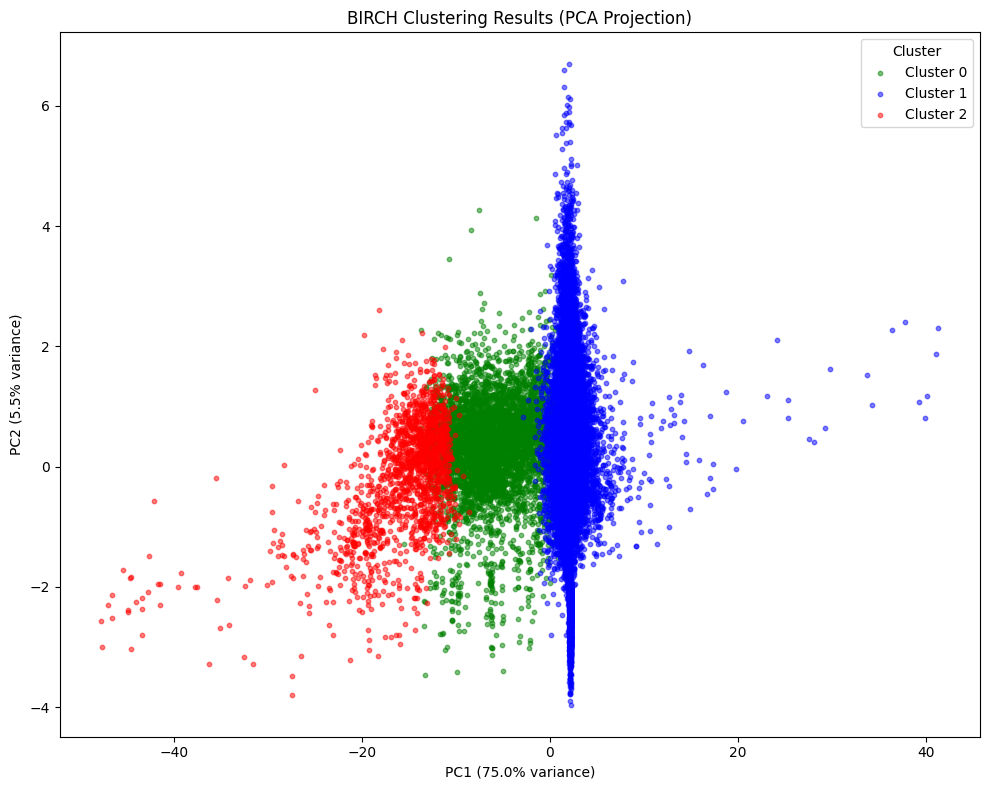

In [57]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Plot clusters with discrete legend
plt.figure(figsize=(10, 8))

colors = ['green', 'blue', 'red']  # Match viridis-like colors
for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('BIRCH Clustering Results (PCA Projection)')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()


PCA Loadings (Feature Contributions):
                              PC1    PC2
avg_submission_delay        0.995  0.033
avg_clicks_per_day         -0.048  0.420
late_submissions_count      0.047  0.473
code_module_FFF            -0.042 -0.023
total_submissions          -0.039  0.269
activity_diversity_ratio   -0.028  0.322
sites_revisit_ratio        -0.027  0.564
code_module_BBB             0.020  0.002
module_presentation_length -0.016 -0.005
code_module_DDD             0.012 -0.044
gender_M                   -0.011  0.002
code_module_CCC             0.011  0.032
tma_cma_weighted_score     -0.010  0.170
code_module_GGG            -0.010 -0.005
num_of_prev_attempts       -0.009 -0.167
code_module_EEE             0.007  0.029
studied_credits             0.005 -0.110
code_presentation_2013J    -0.005 -0.009
code_presentation_2014B     0.003 -0.004
date_registration          -0.002  0.173
imd_band                   -0.002  0.022
age_band                   -0.002  0.019
highest_education  

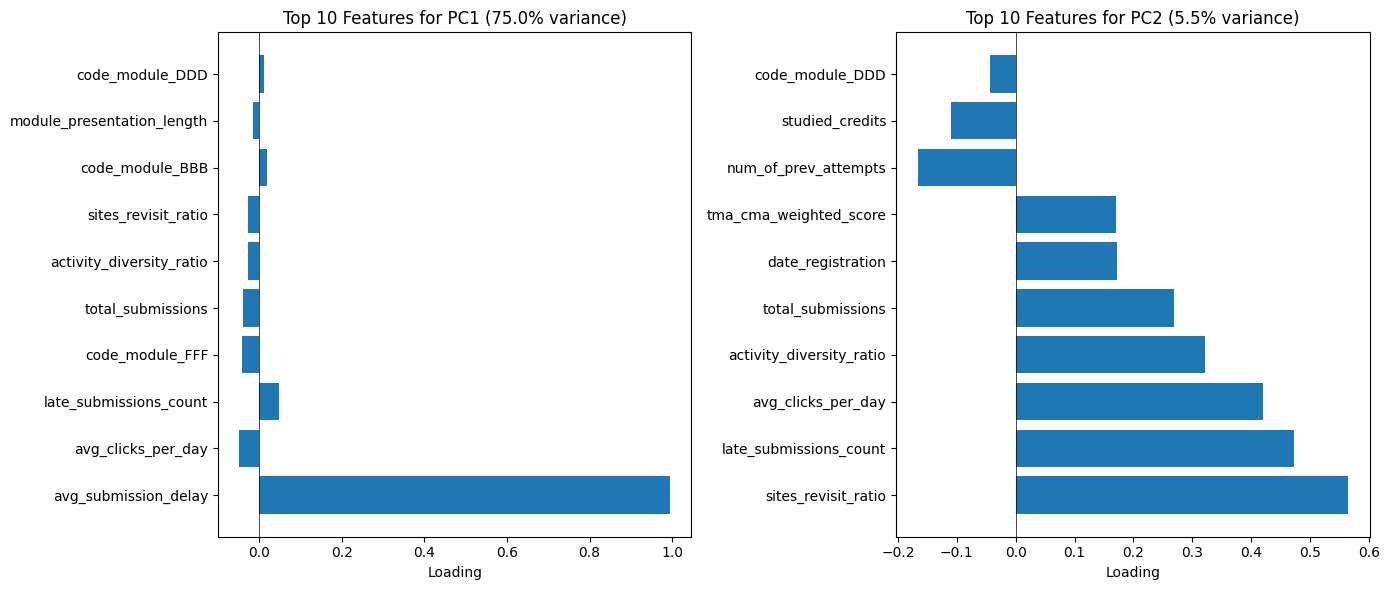

In [58]:
# Get PCA loadings (feature contributions to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns
)

# Sort by absolute contribution to PC1
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings_sorted = loadings.sort_values('PC1_abs', ascending=False).drop('PC1_abs', axis=1)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# Plot top 10 features for each PC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 loadings
top_pc1 = loadings['PC1'].abs().nlargest(10).index
axes[0].barh(range(10), loadings.loc[top_pc1, 'PC1'])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top_pc1)
axes[0].set_xlabel('Loading')
axes[0].set_title(f'Top 10 Features for PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# PC2 loadings
top_pc2 = loadings['PC2'].abs().nlargest(10).index
axes[1].barh(range(10), loadings.loc[top_pc2, 'PC2'])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top_pc2)
axes[1].set_xlabel('Loading')
axes[1].set_title(f'Top 10 Features for PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


## 2. BIRCH Clustering

BIRCH parameters:
- **threshold**: Maximum radius of a subcluster (controls cluster granularity)
- **branching_factor**: Maximum number of subclusters per node
- **n_clusters**: Final number of clusters


## 2.1 Finding Optimal Number of Clusters

Use Silhouette Score and Elbow Method to determine the best k value.


k=2: Silhouette=0.5594
k=3: Silhouette=0.4841
k=4: Silhouette=0.3191
k=5: Silhouette=0.3169
k=6: Silhouette=0.2112
k=7: Silhouette=0.1991
k=8: Silhouette=0.1599


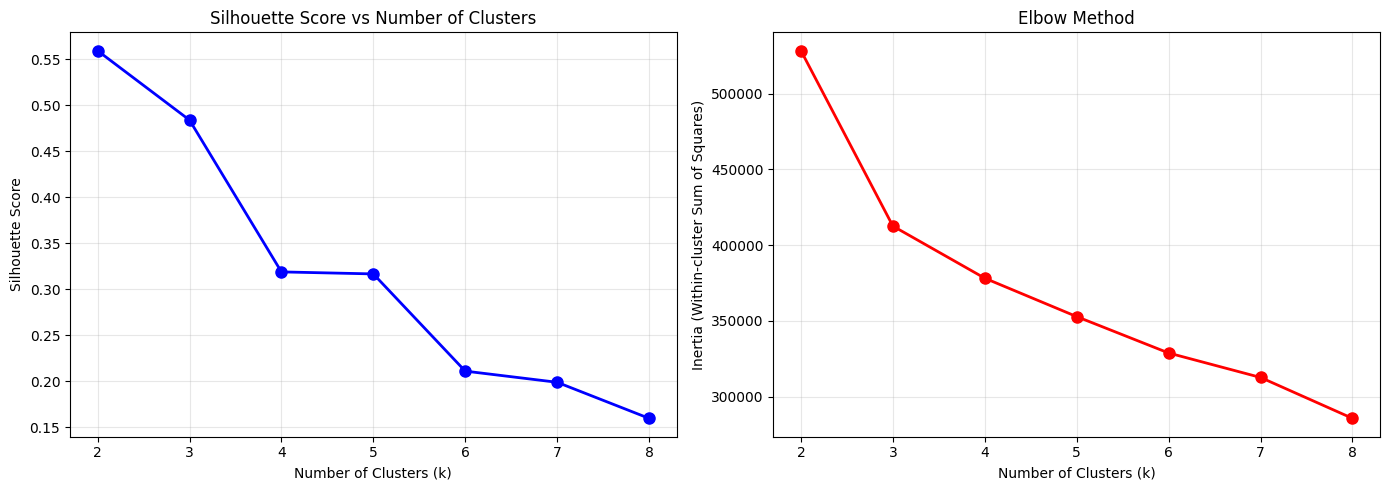

In [59]:
# Test different numbers of clusters
k_range = range(2, 9)
silhouette_scores = []
inertias = []

for k in k_range:
    birch_temp = Birch(threshold=0.5, branching_factor=50, n_clusters=k)
    labels_temp = birch_temp.fit_predict(df)
    
    silhouette_scores.append(silhouette_score(df, labels_temp))
    
    # Calculate inertia (within-cluster sum of squares)
    inertia = 0
    for i in range(k):
        cluster_points = df[labels_temp == i]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean()
            inertia += ((cluster_points - centroid) ** 2).sum().sum()
    inertias.append(inertia)
    
    print(f"k={k}: Silhouette={silhouette_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score Plot
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Elbow Plot
axes[1].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[1].set_title('Elbow Method')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2 Inplementing Clusters by using the specified k

Number of clusters found: 3

Cluster distribution:
cluster
0     4894
1    26031
2     1623
Name: count, dtype: int64


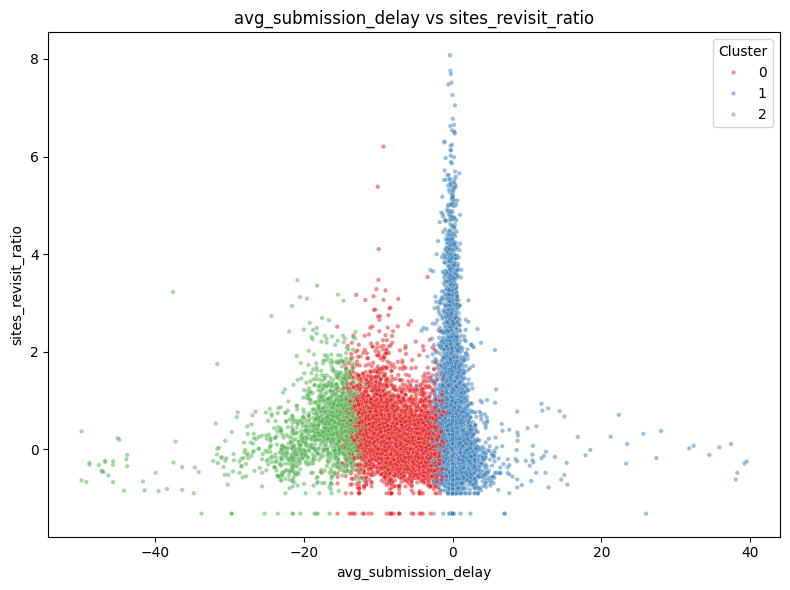

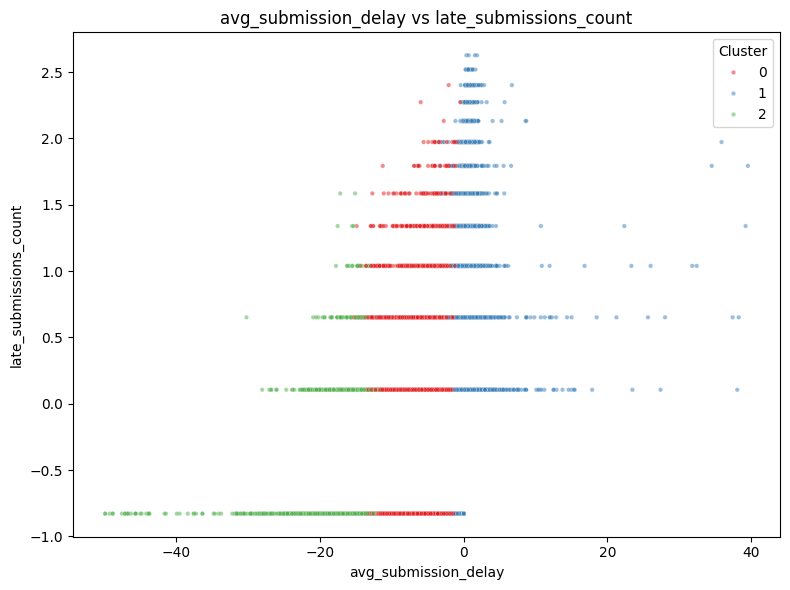

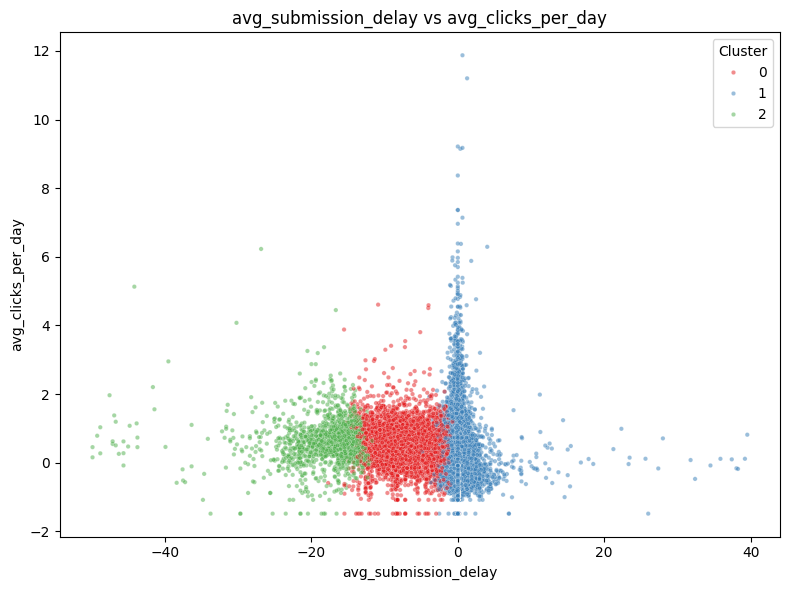

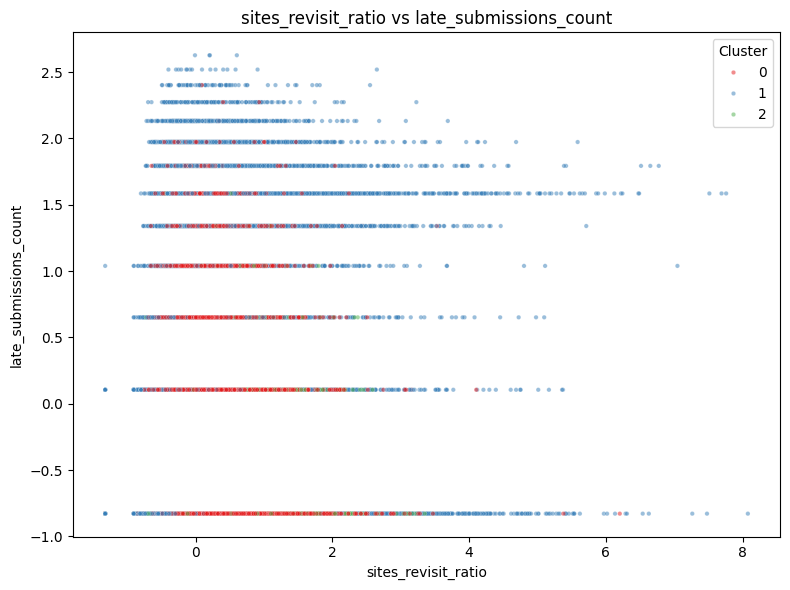

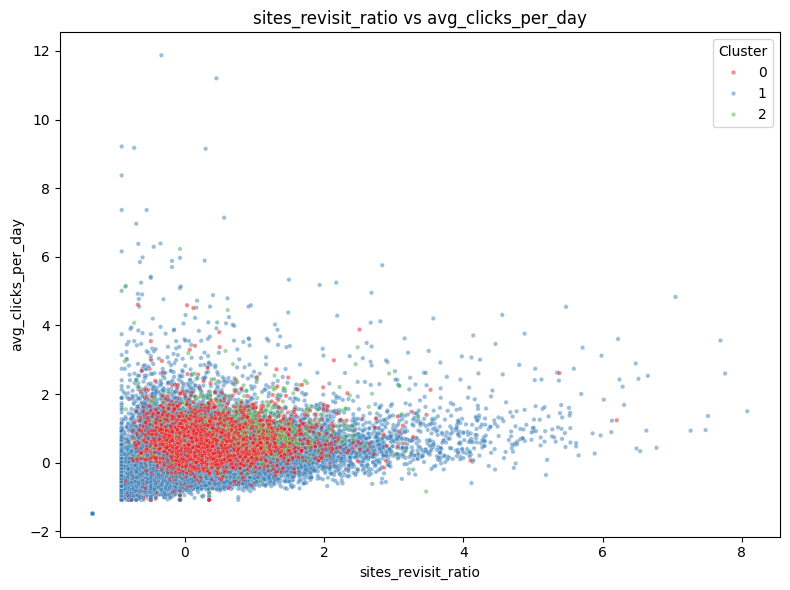

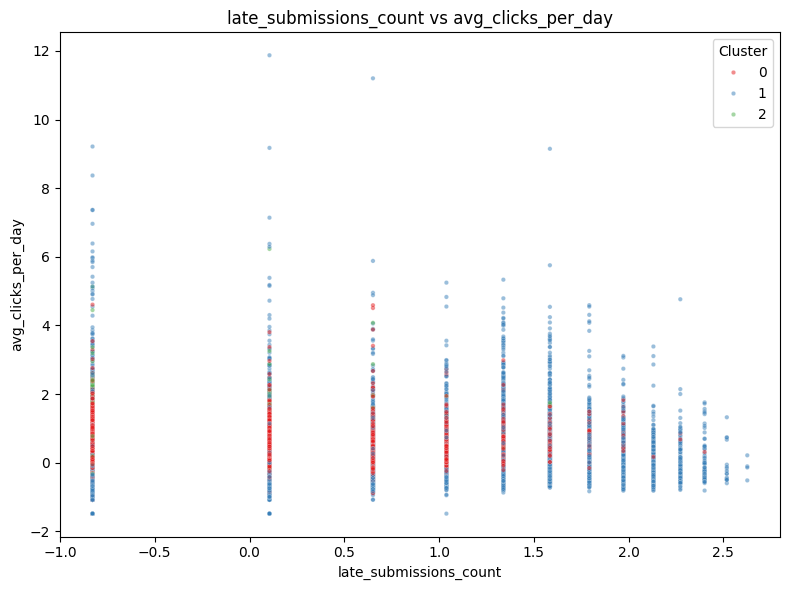

In [30]:
# Initialize and fit BIRCH
birch = Birch(
    threshold=0.5,
    branching_factor=50,
    n_clusters=3  # Let BIRCH determine optimal subclusters first
)

# Fit and predict
cluster_labels = birch.fit_predict(df)

# Add cluster labels to dataframe
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"Number of clusters found: {len(np.unique(cluster_labels))}")
print(f"\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())

# Top PCA features
features = [
    'avg_submission_delay',    # PC1 dominant (0.995)
    'sites_revisit_ratio',     # PC2 top 1 (0.564)
    'late_submissions_count',  # PC2 top 2 (0.473)
    'avg_clicks_per_day',      # PC2 top 3 (0.420)
]

# Generate all pairwise combinations
from itertools import combinations

for x_feat, y_feat in combinations(features, 2):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_feat, y=y_feat, data=df_clustered,
                    hue='cluster', palette='Set1', alpha=0.5, s=10)
    plt.xlabel(x_feat)
    plt.ylabel(y_feat)
    plt.title(f'{x_feat} vs {y_feat}')
    plt.legend(title='Cluster', loc='best')
    plt.tight_layout()
    plt.show()




Cluster Statistics:
   Cluster  Count  Avg_submission_delay  Avg_sites_revisit_ratio  \
0        0   4894             -8.068410                 0.320688   
1        1  26031              0.059879                 0.032112   
2        2   1623            -17.771809                 0.443279   

   Avg_late_submissions  Avg_clicks_per_day  
0             -0.278281            0.531424  
1              0.088692           -0.112242  
2             -0.583384            0.630598  


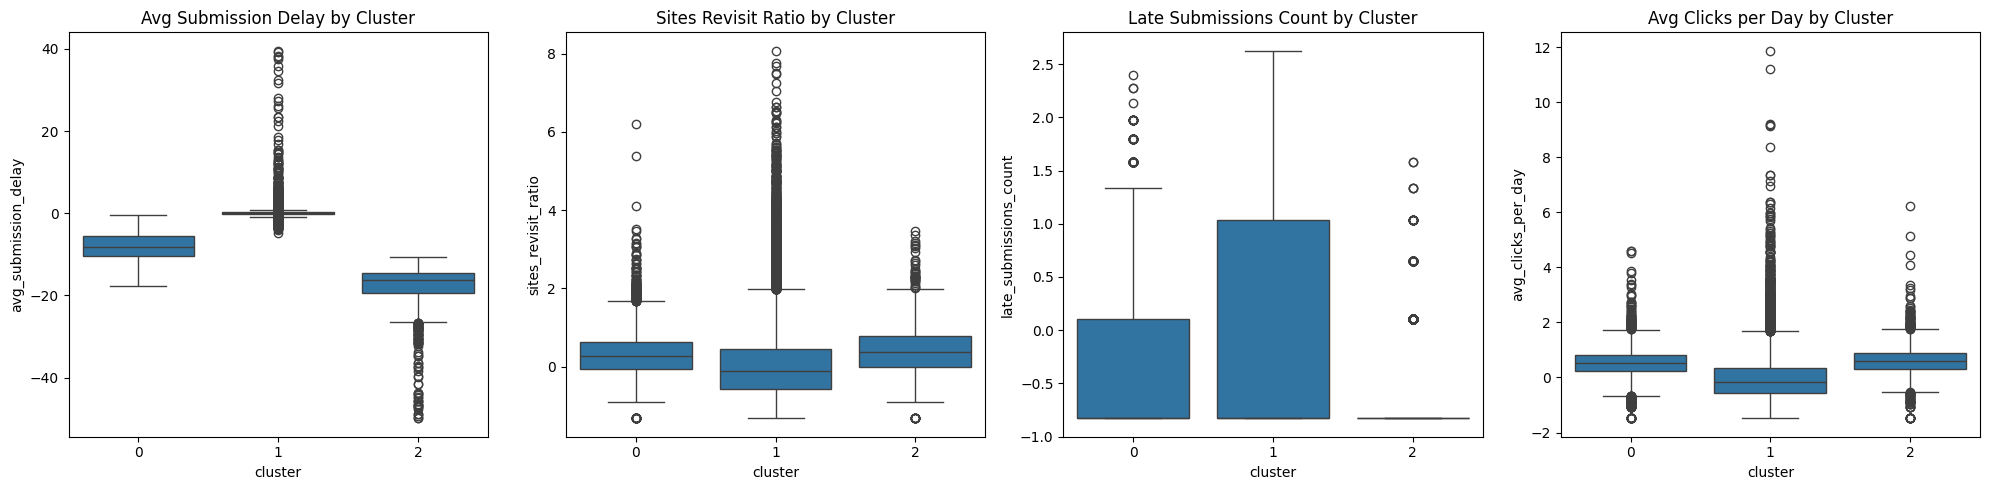

In [49]:
# Cluster statistics for top PCA features
print("\nCluster Statistics:")
cluster_stats = df_clustered.groupby('cluster').agg({
    'avg_submission_delay': ['count', 'mean'],
    'sites_revisit_ratio': 'mean',
    'late_submissions_count': 'mean',
    'avg_clicks_per_day': 'mean'
}).reset_index()

cluster_stats.columns = ['Cluster', 'Count', 'Avg_submission_delay', 
                         'Avg_sites_revisit_ratio', 'Avg_late_submissions', 
                         'Avg_clicks_per_day']
print(cluster_stats)

# Boxplots for top PCA features
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.boxplot(x='cluster', y='avg_submission_delay', data=df_clustered, ax=axes[0])
axes[0].set_title('Avg Submission Delay by Cluster')

sns.boxplot(x='cluster', y='sites_revisit_ratio', data=df_clustered, ax=axes[1])
axes[1].set_title('Sites Revisit Ratio by Cluster')

sns.boxplot(x='cluster', y='late_submissions_count', data=df_clustered, ax=axes[2])
axes[2].set_title('Late Submissions Count by Cluster')

sns.boxplot(x='cluster', y='avg_clicks_per_day', data=df_clustered, ax=axes[3])
axes[3].set_title('Avg Clicks per Day by Cluster')

plt.tight_layout()
plt.show()

## 3. Cluster Evaluation

Evaluate clustering quality using:
- **Silhouette Score**: Measures how similar points are to their own cluster vs other clusters (-1 to 1, higher is better)
- **Calinski-Harabasz Index**: Ratio of between-cluster to within-cluster variance (higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)


In [50]:
# Calculate evaluation metrics
silhouette = silhouette_score(df, cluster_labels)
calinski = calinski_harabasz_score(df, cluster_labels)
davies = davies_bouldin_score(df, cluster_labels)

print("=" * 50)
print("CLUSTERING EVALUATION METRICS")
print("=" * 50)
print(f"\nSilhouette Score:        {silhouette:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index:    {davies:.4f}")


CLUSTERING EVALUATION METRICS

Silhouette Score:        0.4841
Calinski-Harabasz Index: 27809.3663
Davies-Bouldin Index:    0.8604


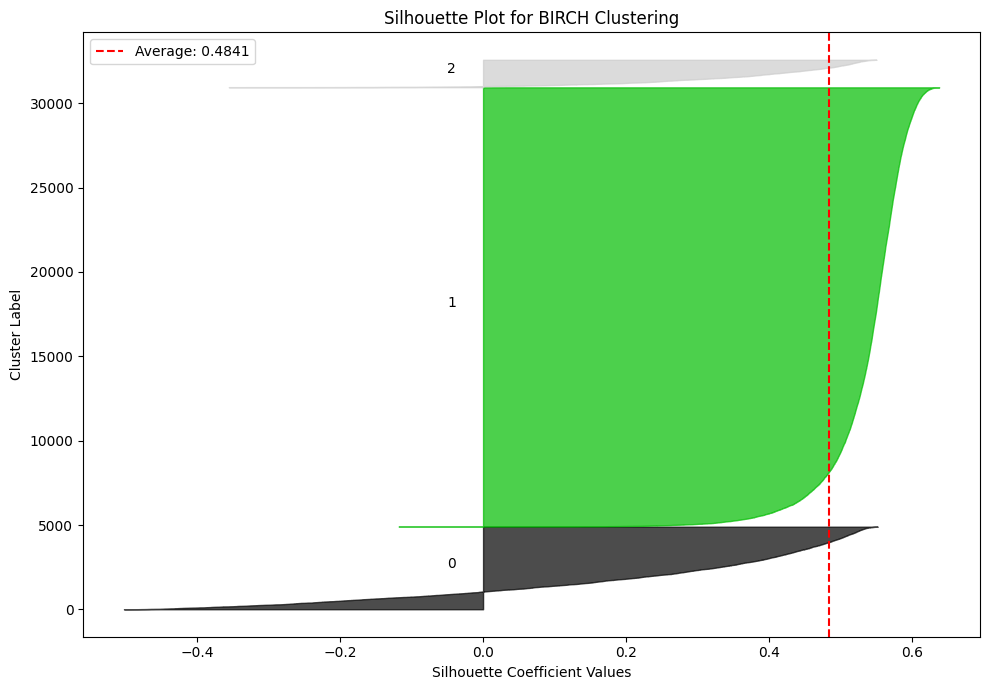

In [51]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# Calculate silhouette scores
silhouette_avg = silhouette_score(df, cluster_labels)
sample_silhouette_values = silhouette_samples(df, cluster_labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
n_clusters = len(np.unique(cluster_labels))
colors = cm.nipy_spectral(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.set_title('Silhouette Plot for BIRCH Clustering')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster Label')
ax.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'Average: {silhouette_avg:.4f}')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 5. Cluster Profiling

Analyze the characteristics of each cluster by examining feature means.


In [52]:
# Calculate cluster statistics
cluster_stats = df_clustered.groupby('cluster').mean()

print("=" * 50)
print("CLUSTER PROFILES (Feature Means)")
print("=" * 50)
print(f"\nNumber of samples per cluster:")
print(df_clustered['cluster'].value_counts().sort_index())
print(f"\n")
cluster_stats.T


CLUSTER PROFILES (Feature Means)

Number of samples per cluster:
cluster
0     4894
1    26031
2     1623
Name: count, dtype: int64




cluster,0,1,2
highest_education,0.414998,0.439015,0.428373
imd_band,0.469237,0.453365,0.463476
age_band,0.162648,0.147709,0.175293
num_of_prev_attempts,0.025436,-0.012701,0.127009
studied_credits,0.131828,0.358556,0.440953
date_registration,0.166013,-0.026101,-0.081971
avg_clicks_per_day,0.531424,-0.112242,0.630598
module_presentation_length,-0.010522,-0.026069,0.449843
tma_cma_weighted_score,0.442907,0.364763,0.548864
total_submissions,0.563394,-0.080222,0.447705


# Further analysis

Outcome Counts per Cluster:
final_result  Distinction  Fail  Pass  Withdrawn
cluster                                         
0                     806   745  3045        298
1                    1960  5941  8688       9442
2                     258   361   627        377

Outcome Rates (%) per Cluster:
final_result  Distinction   Fail   Pass  Withdrawn
cluster                                           
0                   16.47  15.22  62.22       6.09
1                    7.53  22.82  33.38      36.27
2                   15.90  22.24  38.63      23.23


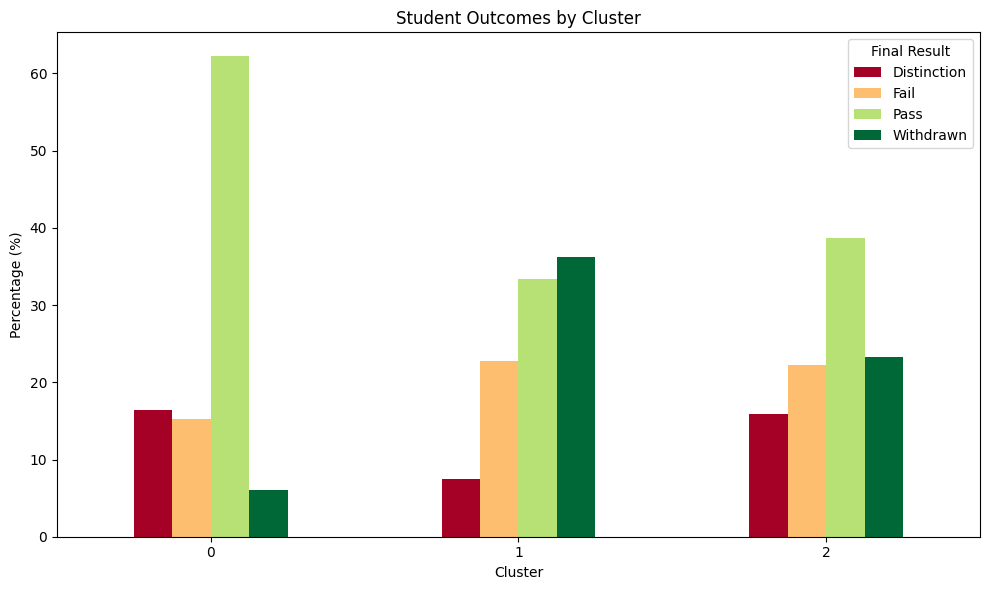


Cluster 0:
  Total students: 4894
  Distinction: 16.5%
  Fail: 15.2%
  Pass: 62.2%
  Withdrawn: 6.1%

Cluster 1:
  Total students: 26031
  Distinction: 7.5%
  Fail: 22.8%
  Pass: 33.4%
  Withdrawn: 36.3%

Cluster 2:
  Total students: 1623
  Distinction: 15.9%
  Fail: 22.2%
  Pass: 38.6%
  Withdrawn: 23.2%
Simplified Outcome Counts per Cluster:
outcome_simplified  Pass and Distinction  Fail  Withdrawn
cluster                                                  
0                                   3851   745        298
1                                  10648  5941       9442
2                                    885   361        377

Simplified Outcome Rates (%) per Cluster:
outcome_simplified  Pass and Distinction   Fail  Withdrawn
cluster                                                   
0                                  78.69  15.22       6.09
1                                  40.91  22.82      36.27
2                                  54.53  22.24      23.23


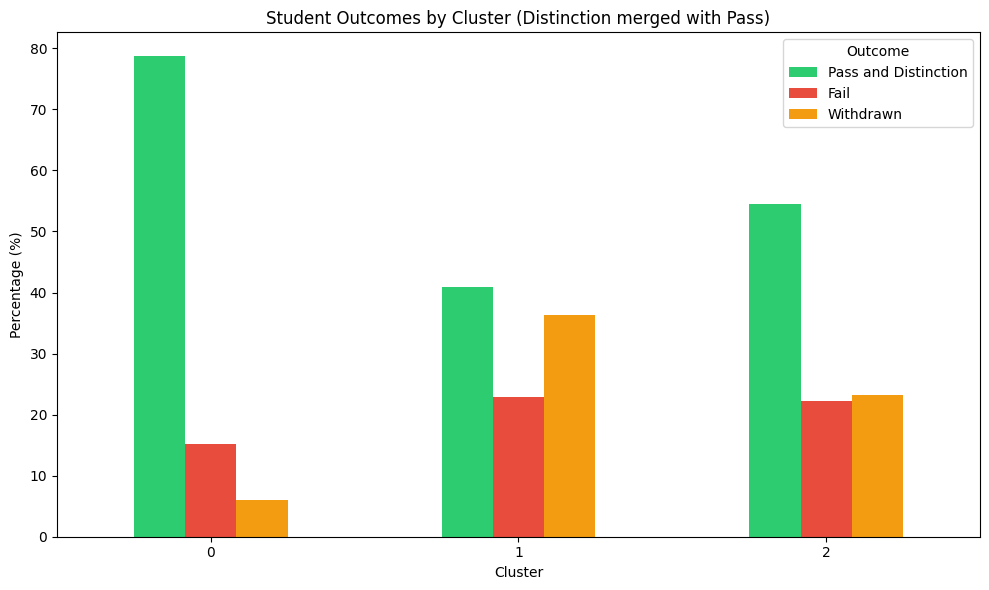


Cluster 0 (n=4894):
  Pass and Distinction: 78.7%
  Fail: 15.2%
  Withdrawn: 6.1%

Cluster 1 (n=26031):
  Pass and Distinction: 40.9%
  Fail: 22.8%
  Withdrawn: 36.3%

Cluster 2 (n=1623):
  Pass and Distinction: 54.5%
  Fail: 22.2%
  Withdrawn: 23.2%


In [53]:
# Load original data with final_result
original_df = pd.read_csv('../data/merged/merged_1.csv')

# Add cluster labels to original data
original_df['cluster'] = cluster_labels

# Cross-tabulation: cluster vs final_result
outcome_counts = pd.crosstab(original_df['cluster'], original_df['final_result'])
outcome_rates = pd.crosstab(original_df['cluster'], original_df['final_result'], normalize='index') * 100

print("Outcome Counts per Cluster:")
print(outcome_counts)
print("\nOutcome Rates (%) per Cluster:")
print(outcome_rates.round(2))

# Plot outcome rates
outcome_rates.plot(kind='bar', figsize=(10, 6), colormap='RdYlGn')
plt.title('Student Outcomes by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Final Result')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary
for cluster in sorted(original_df['cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(f"  Total students: {len(original_df[original_df['cluster'] == cluster])}")
    for outcome in outcome_rates.columns:
        rate = outcome_rates.loc[cluster, outcome]
        print(f"  {outcome}: {rate:.1f}%")




# Create simplified outcome (merge Distinction + Pass)
original_df['outcome_simplified'] = original_df['final_result'].replace({
    'Distinction': 'Pass and Distinction',
    'Pass': 'Pass and Distinction',
    'Fail': 'Fail',
    'Withdrawn': 'Withdrawn'
})

# Cross-tabulation with simplified outcomes
outcome_counts_simple = pd.crosstab(original_df['cluster'], original_df['outcome_simplified'])
outcome_rates_simple = pd.crosstab(original_df['cluster'], original_df['outcome_simplified'], normalize='index') * 100

# Reorder columns
col_order = ['Pass and Distinction', 'Fail', 'Withdrawn']
outcome_counts_simple = outcome_counts_simple[col_order]
outcome_rates_simple = outcome_rates_simple[col_order]

print("Simplified Outcome Counts per Cluster:")
print(outcome_counts_simple)
print("\nSimplified Outcome Rates (%) per Cluster:")
print(outcome_rates_simple.round(2))

# Plot simplified outcome rates
colors = ['#2ecc71', '#e74c3c', '#f39c12']  # Green, Red, Orange
outcome_rates_simple.plot(kind='bar', figsize=(10, 6), color=colors)
plt.title('Student Outcomes by Cluster (Distinction merged with Pass)')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Outcome')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary
for cluster in sorted(original_df['cluster'].unique()):
    print(f"\nCluster {cluster} (n={len(original_df[original_df['cluster'] == cluster])}):")
    for outcome in col_order:
        rate = outcome_rates_simple.loc[cluster, outcome]
        print(f"  {outcome}: {rate:.1f}%")



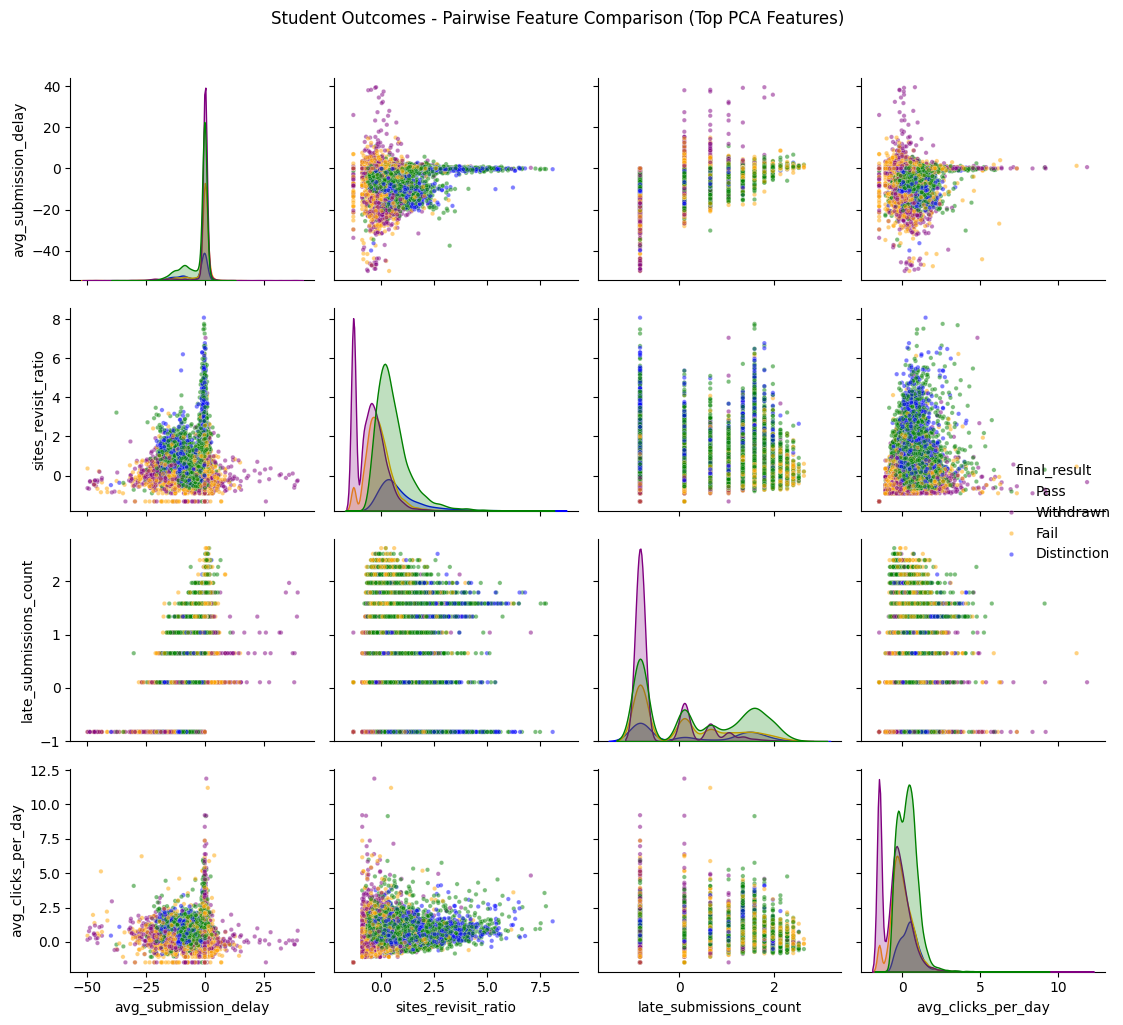

In [54]:
# Load original data to get final_result
original_df = pd.read_csv('../data/merged/merged_1.csv')

# Add final_result to df_clustered
df_clustered['final_result'] = original_df['final_result']

# Custom color palette: Withdrawn=purple, Fail=orange, Pass=green, Distinction=blue
custom_palette = {
    'Withdrawn': 'purple',
    'Fail': 'orange',
    'Pass': 'green',
    'Distinction': 'blue'
}

# Pairwise scatter plots colored by final_result
selected_features = [
    'avg_submission_delay',    # PC1 dominant (0.995)
    'sites_revisit_ratio',     # PC2 top 1 (0.564)
    'late_submissions_count',  # PC2 top 2 (0.473)
    'avg_clicks_per_day',      # PC2 top 3 (0.420)
    'final_result'
]

sns.pairplot(df_clustered[selected_features], hue='final_result', palette=custom_palette,
             plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Student Outcomes - Pairwise Feature Comparison (Top PCA Features)', y=1.02)
plt.tight_layout()
plt.show()